<a href="https://colab.research.google.com/github/Vinutha-Reddy/Internship-Projects/blob/main/Project_04_ML_Classification_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Project Title - Customer Churn Prediction (Classification)**

# **2. Problem Statement**
Customer churn is a major concern for businesses, especially in industries like telecom,
banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.
In this project, the goal is to build a Machine Learning classification model that predicts
whether a customer will leave the company (Churn: Yes/No) based on features such as:
- Customer Age
- Gender
- Tenure
- Monthly Charges
- Total Charges
- Contract Type
- Payment Method
- Internet Service
- Tech Support
- Online Security
- Customer Support Calls

Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting customer churn.

# **3. Project Objectives**
The objective of this task is to:
- Understand and explore the customer dataset
- Perform data preprocessing (missing values, duplicates, outliers)
- Conduct Exploratory Data Analysis (EDA)
- Apply encoding and feature scaling
- Train multiple classification algorithms
- Evaluate models using classification metrics
- Perform cross-validation and hyperparameter tuning
- Select the best-performing model

# **4. Tools and Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **5. Dataset Loading**

In [ ]:
data = pd.read_csv('customer_churn_data.csv')
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# **6. Preliminary Data Exploration**

In [ ]:
# Dataset Shape
data.shape

(7043, 21)

There are **7043 rows** and **21 columns**

In [ ]:
# Head
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [ ]:
# Tail
data.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
# Dataset Information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7041 non-null   object 


In [ ]:
# Data Types
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
# Statistical Summary
# Numeric Columns
num_data=data.select_dtypes(include=['int64','float64'])
num_data

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [ ]:
# Statistical report of Numerical data
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Categorical Columns
cat_data=data.select_dtypes(include=['object'])
cat_data

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,1889.5,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,108.15,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),1840.75,No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Electronic check,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,1990.5,No
7039,2234-XADUH,Female,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),7362.9,No
7040,4801-JZAZL,Female,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,346.45,No
7041,8361-LTMKD,Male,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,306.6,Yes


In [ ]:
# Statistical report of Categorical data
data.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7038,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7041,7043,7038,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6526,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3550,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4169,2365,11,5174


In [ ]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# Unique Values
df = data.drop(['customerID','tenure','MonthlyCharges','TotalCharges'], axis=1, errors='ignore')
for x in df:
    print(f"{x} --> {df[x].unique()}")
    print()

gender --> ['Female' 'Male' nan]

SeniorCitizen --> [0 1]

Partner --> ['Yes' 'No']

Dependents --> ['No' 'Yes']

PhoneService --> ['No' 'Yes']

MultipleLines --> ['No phone service' 'No' 'Yes']

InternetService --> ['DSL' 'Fiber optic' 'No']

OnlineSecurity --> ['No' 'Yes' 'No internet service']

OnlineBackup --> ['Yes' 'No' 'No internet service']

DeviceProtection --> ['No' 'Yes' 'No internet service']

TechSupport --> ['No' 'Yes' 'No internet service']

StreamingTV --> ['No' 'Yes' 'No internet service']

StreamingMovies --> ['No' 'Yes' 'No internet service']

Contract --> ['Month-to-month' 'One year' 'Two year']

PaperlessBilling --> ['Yes' 'No' nan]

PaymentMethod --> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn --> ['No' 'Yes']



In [ ]:
# Value Counts
for x in df:
    print(df[x].value_counts())
    print()

gender
Male      3550
Female    3488
Name: count, dtype: int64

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
No                     3473
Yes                    2044
No internet service    15

In [ ]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# **7. Data Cleaning and Preparation**

In [ ]:
# Convert datatype of TotalCharges from object to numerical
data['totalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [ ]:
data.drop(columns=['TotalCharges'], inplace=True)

**7.1 Duplicate Handling**

In [ ]:
data.duplicated().sum()

np.int64(0)

There are **no duplicate values** in the data.

**7.2 Missing Value Treatment**

In [ ]:
data.isnull().sum()

,0
customerID,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


There are **missing values** in **gender, PaperlessBilling, MonthlyCharges, totalCharges** in the data.

**Handling Missing Values**

**a. gender**

In [ ]:
# Check datatype
data.loc[:,'gender'].dtype

dtype('O')

Since the **datatype** of **gender** is **object**, **replace with mode**.

In [ ]:
# Find mode
data.loc[:,'gender'].mode()[0]

'Male'

In [ ]:
# Fill with mode
data.loc[:,'gender']=data.loc[:,'gender'].fillna(data.loc[:,'gender'].mode()[0])

In [ ]:
# Check missing
data.loc[:,'gender'].isnull().sum()

np.int64(0)

**b. PaperlessBilling**

In [ ]:
# Check datatype
data.loc[:,'PaperlessBilling'].dtype

dtype('O')

Since the **datatype** of **PaperlessBilling** is **object**, **replace with mode**.

In [ ]:
# Find mode
data.loc[:,'PaperlessBilling'].mode()[0]

'Yes'

In [ ]:
# Fill with mode
data.loc[:,'PaperlessBilling']=data.loc[:,'PaperlessBilling'].fillna(data.loc[:,'PaperlessBilling'].mode()[0])

In [ ]:
# Check missing
data.loc[:,'PaperlessBilling'].isnull().sum()

np.int64(0)

**c. MonthlyCharges**

In [ ]:
# Check datatype
data.loc[:,'MonthlyCharges'].dtype

dtype('float64')

Since the **datatype** of **MonthlyCharges** is **numerical**, **find the skewness** and replace with:
1. If **skewness** value is within **[-0.5,0.5]** --> **normal distribution** --> replace with **mean**
2. If **skewness** value is **greater than 0.5** --> **right skewed** --> replace with **median**
3. If **skewness** value is **less than -0.5** --> **left skewed** --> replace with **median**

In [ ]:
# Find Skewness
data.loc[:,'MonthlyCharges'].skew()

np.float64(-0.22028439456532767)

**Skewness** of **MonthlyCharges** is **-0.2** which is within **[-.5,.5]**. Hence the **distribution** of **MonthlyCharges** is **normal distribution**. So we replace **missing values** with **mean**.

In [ ]:
# Find mean
data.loc[:,'MonthlyCharges'].mean()

np.float64(64.74958102542253)

In [ ]:
# fill with mean
data.loc[:,'MonthlyCharges']=data.loc[:,'MonthlyCharges'].fillna(data.loc[:,'MonthlyCharges'].mean())

In [ ]:
# Check missing
data.loc[:,'MonthlyCharges'].isnull().sum()

np.int64(0)

**d. totalCharges**

In [ ]:
# Check datatype
data.loc[:,'totalCharges'].dtype

dtype('float64')

Since the **datatype** of **tota;Charges** is **numerical**, **find the skewness** and replace with:
1. If **skewness** value is within **[-0.5,0.5]** --> **normal distribution** --> replace with **mean**
2. If **skewness** value is **greater than 0.5** --> **right skewed** --> replace with **median**
3. If **skewness** value is **less than -0.5** --> **left skewed** --> replace with **median**

In [ ]:
# Find Skewness
data.loc[:,'totalCharges'].skew()

np.float64(0.9616058347613503)

**Skewness** of **totalCharges** is **0.9** which is **greater than 0.5**. Hence the **distribution** of **MonthlyCharges** is **right skewed**. So we replace **missing values** with **median**.

In [ ]:
# Find median
data.loc[:,'totalCharges'].median()

1397.3

In [ ]:
# Fill with median
data.loc[:,'totalCharges']=data.loc[:,'totalCharges'].fillna(data.loc[:,'totalCharges'].mode()[0])

In [ ]:
# Check missing
data.loc[:,'totalCharges'].isnull().sum()

np.int64(0)

In [ ]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# **8. Data Visualization and Analysis**

**8.1 Univariate Analysis**

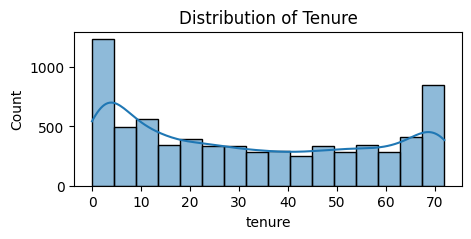

In [ ]:
# Distribution of tenure
plt.figure(figsize=(5,2))
sns.histplot(data['tenure'], kde=True)
plt.title("Distribution of Tenure")
plt.show()

**Insights**

* The **tenure distribution** is **skewed**, with a **high concentration** of customers in the **lower tenure range (0–10 months)**.

* There is a noticeable **decline in frequency** as tenure increases, indicating **fewer mid-term customers** compared to new ones.

* Towards the higher end (around **65–72 months**), there is a **slight increase**, suggesting a group of **long-term loyal customers**.

* Overall, the graph shows a **bimodal tendency**, with peaks at **early-stage** and **long-term tenure**, but fewer customers in the **middle duration**.


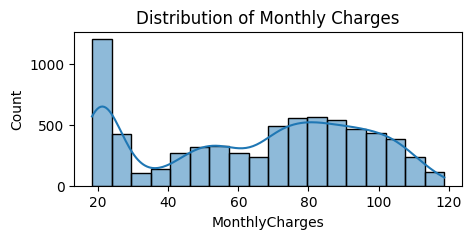

In [ ]:
# Distribution of MonthlyCharges
plt.figure(figsize=(5,2))
sns.histplot(data['MonthlyCharges'], kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()

**Insights**

* The **monthly charges distribution** shows a **high concentration** of customers in the **low price range (around 20–30)**.

* There is a **dip in frequency** in the **30–40 range**, indicating **fewer customers** in this mid-low pricing segment.

* A **major peak** is observed between **70–100**, showing that **most customers pay moderate to high charges**.

* The distribution is **right-skewed**, with charges gradually extending towards the **higher range (up to 120)** but with **decreasing frequency**.


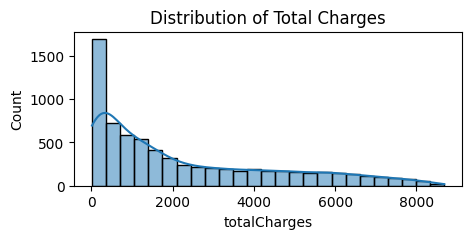

In [ ]:
# Distribution of totalCharges
plt.figure(figsize=(5,2))
sns.histplot(data['totalCharges'], kde=True)
plt.title("Distribution of Total Charges")
plt.show()

**Insights**

* The **total charges distribution** is **highly right-skewed**, with most customers having **low total charges (close to 0–1000)**.

* There is a **sharp decline** in the number of customers as **total charges increase**, indicating **fewer high-paying customers**.

* A **long tail** extends towards **higher values (up to 8000+)**, representing a **small group of long-term or high-paying customers**.

* The graph suggests that the majority of customers are either **new or have shorter tenure**, resulting in **lower accumulated charges**.


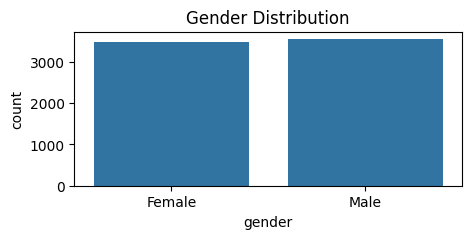

In [ ]:
# Count of customers by gender
plt.figure(figsize=(5,2))
sns.countplot(x='gender', data=data)
plt.title("Gender Distribution")
plt.show()

**Insights**

* The **gender distribution** is **almost equal**, with **male and female customers** having **nearly the same count**.

* There is a **slight dominance** of **male customers**, but the difference is **very minimal**.

* The dataset shows **no significant gender imbalance**, indicating a **well-balanced representation**.

* This balance suggests that **gender is unlikely to heavily influence overall trends** in the dataset.


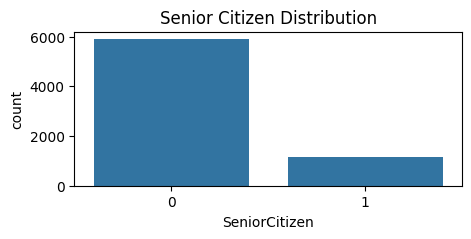

In [ ]:
# Count of SeniorCitizen customers
plt.figure(figsize=(5,2))
sns.countplot(x='SeniorCitizen', data=data)
plt.title("Senior Citizen Distribution")
plt.show()

**Insights**

* The **majority of customers** are **non-senior citizens (0)**, showing a **very high count** compared to seniors.

* **Senior citizens (1)** make up a **small portion** of the dataset, indicating **low representation**.

* There is a **significant imbalance** between the two groups, with **non-seniors dominating** the data.

* This suggests that **most services are used by younger or middle-aged customers**, while **senior customer participation is limited**.


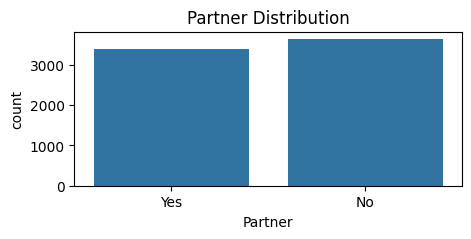

In [ ]:
# Distribution of Partner
plt.figure(figsize=(5,2))
sns.countplot(x='Partner', data=data)
plt.title("Partner Distribution")
plt.show()

**Insights**

* The number of customers with **no partner** is slightly **higher** than those with a **partner**.
* Both categories show a **similar distribution**, indicating no major imbalance.
* A **significant portion** of customers fall into both groups, suggesting partner status is **evenly spread**.
* The difference between the two groups is **small**, so partner status may have **limited impact** overall.


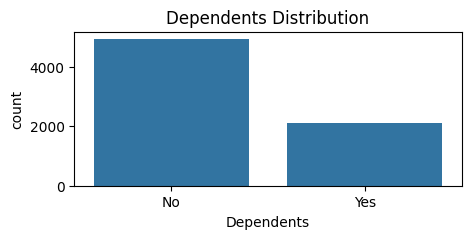

In [ ]:
# Distribution of Dependents
plt.figure(figsize=(5,2))
sns.countplot(x='Dependents', data=data)
plt.title("Dependents Distribution")
plt.show()

**Insights**

* A majority of customers have **no dependents**, showing a **higher count** compared to those with dependents.
* Customers with **dependents** are **significantly fewer**, indicating an **uneven distribution**.
* The gap between **No** and **Yes** categories is quite **large**, highlighting a clear **dominance** of one group.
* This suggests that most customers are likely **independent individuals** rather than those supporting dependents.


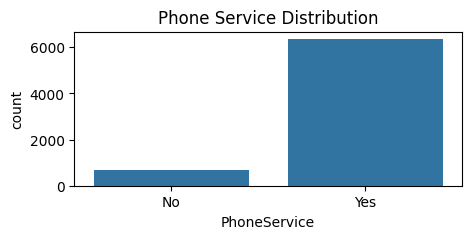

In [ ]:
# Distribution of PhoneService
plt.figure(figsize=(5,2))
sns.countplot(x='PhoneService', data=data)
plt.title("Phone Service Distribution")
plt.show()

**Insights**

* A vast majority of customers have **phone service**, showing a **very high count** compared to those without.
* Customers with **no phone service** are **very few**, indicating a **strong imbalance**.
* The difference between **Yes** and **No** categories is **extremely large**, highlighting clear **dominance** of phone service users.
* This suggests that having **phone service** is a **common feature** among most customers.


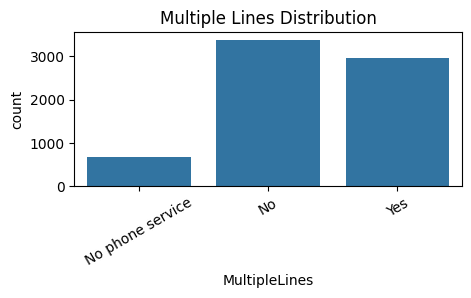

In [ ]:
# Distribution of MultipleLines
plt.figure(figsize=(5,2))
sns.countplot(x='MultipleLines', data=data)
plt.title("Multiple Lines Distribution")
plt.xticks(rotation=30)
plt.show()

**Insights**

* The highest number of customers fall under **no multiple lines**, showing it is the **most common** category.
* Customers with **multiple lines (Yes)** are also **significant**, but slightly **less** than those with no multiple lines.
* The **no phone service** category has a **very low count**, indicating very **few users** without phone service.
* Overall, most customers either have **single line** or **multiple lines**, with very **few exceptions**.


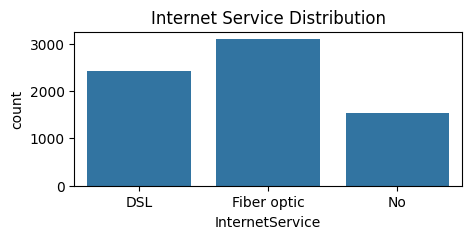

In [ ]:
# Distribution of InternetService
plt.figure(figsize=(5,2))
sns.countplot(x='InternetService', data=data)
plt.title("Internet Service Distribution")
plt.show()

**Insights**

* **Fiber optic** service has the **highest number** of customers, making it the **most preferred** option.
* **DSL** users are also **significant**, but clearly **less** than fiber optic users.
* Customers with **no internet service** are **fewer**, indicating most customers use some form of **internet service**.
* Overall, there is a **strong preference** towards **high-speed internet (fiber optic)** among customers.


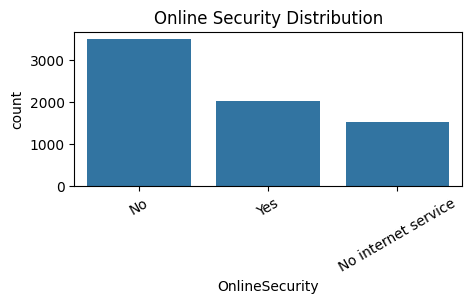

In [ ]:
# Distribution of OnlineSecurity
plt.figure(figsize=(5,2))
sns.countplot(x='OnlineSecurity', data=data)
plt.title("Online Security Distribution")
plt.xticks(rotation=30)
plt.show()

**Insights**

* The **majority of customers** fall under **no online security**, indicating low **adoption of security features**.

* A comparatively smaller group has **online security enabled**, showing only **moderate usage** among users.

* A noticeable portion of customers have **no internet service**, reflecting a segment **not engaged in online services**.

* The distribution suggests a clear **gap in security awareness or usage**, with many users either **not opting for** or **not requiring** online security.


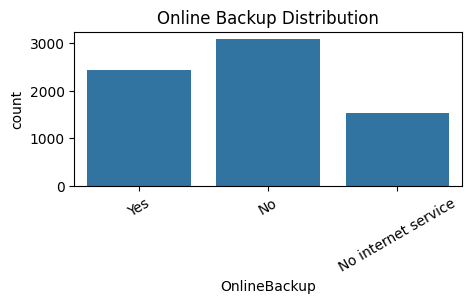

In [ ]:
# Distribution of OnlineBackup
plt.figure(figsize=(5,2))
sns.countplot(x='OnlineBackup', data=data)
plt.title("Online Backup Distribution")
plt.xticks(rotation=30)
plt.show()

**Insights**

* The **largest group of customers** does **not use online backup**, indicating low **adoption of backup services**.

* A smaller yet considerable segment has **online backup enabled**, showing **partial usage** among users.

* A noticeable portion falls under **no internet service**, highlighting users **not involved in online features**.

* The trend reflects a **gap in data protection practices**, with many users **not prioritizing backup solutions**.


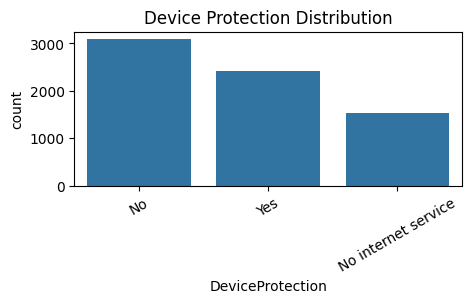

In [ ]:
# Distribution of DeviceProtection
plt.figure(figsize=(5,2))
sns.countplot(x='DeviceProtection', data=data)
plt.title("Device Protection Distribution")
plt.xticks(rotation=30)
plt.show()

**Insights**

* The **majority of customers** do **not have device protection**, indicating low **adoption of protection services**.

* A relatively smaller group has **device protection enabled**, showing **moderate awareness and usage**.

* A consistent segment appears under **no internet service**, reflecting users **not utilizing online-based features**.

* The overall pattern highlights a **gap in device safety measures**, with many users **not opting for protection plans**.


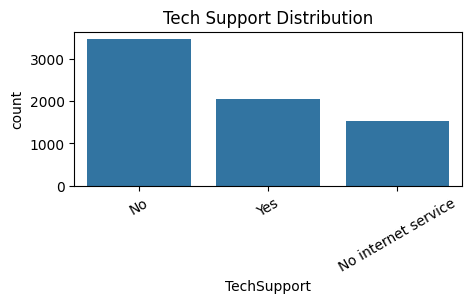

In [ ]:
# Distribution of TechSupport
plt.figure(figsize=(5,2))
sns.countplot(x='TechSupport', data=data)
plt.title("Tech Support Distribution")
plt.xticks(rotation=30)
plt.show()

**Insights**

* The **majority of customers** do **not use tech support**, indicating low **utilization of support services**.

* A smaller segment has **tech support enabled**, reflecting **limited adoption** among users.

* A noticeable group falls under **no internet service**, showing users **not connected to online services**.

* The distribution suggests a **gap in support engagement**, with many users **not opting for assistance services**.


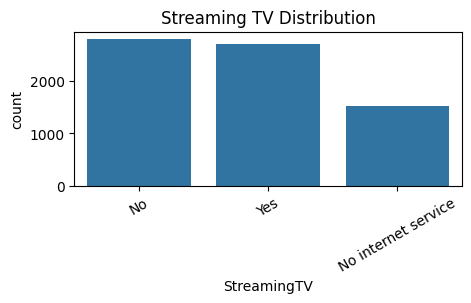

In [ ]:
# Distribution of StreamingTV
plt.figure(figsize=(5,2))
sns.countplot(x='StreamingTV', data=data)
plt.title("Streaming TV Distribution")
plt.xticks(rotation=30)
plt.show()

**Insights**

* The **majority of customers** do **not use streaming TV**, indicating slightly lower **adoption of streaming services**.

* A nearly equal number of users have **streaming TV enabled**, showing **strong but not dominant usage**.

* A smaller segment falls under **no internet service**, reflecting users **not accessing digital entertainment services**.

* The distribution suggests a **balanced preference**, with users being **almost equally divided** between using and not using streaming TV.


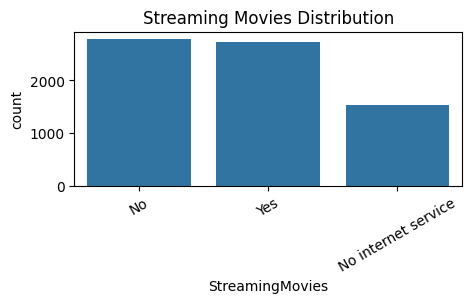

In [ ]:
# Distribution of StreamingMovies
plt.figure(figsize=(5,2))
sns.countplot(x='StreamingMovies', data=data)
plt.title("Streaming Movies Distribution")
plt.xticks(rotation=30)
plt.show()

**Insights**

* The **‘No’ category** has the **highest count**, indicating most users **do not stream movies**.
* The **‘Yes’ category** is **slightly lower** than ‘No’, showing a **significant number still stream movies**, but less than non-streamers.
* The **‘No internet service’ group** has a **much lower count**, suggesting **limited users without internet access**.
* Overall, there is a **clear gap** between users with **internet access vs no internet**, impacting **streaming behavior**.


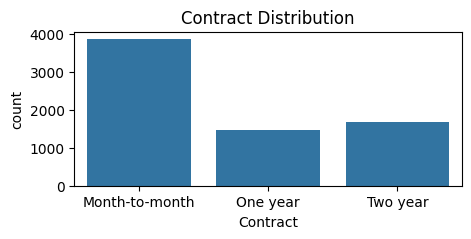

In [ ]:
# Distribution of Contract
plt.figure(figsize=(5,2))
sns.countplot(x='Contract', data=data)
plt.title("Contract Distribution")
plt.show()

**Insights**

* The **‘Month-to-month’ contract** has the **highest count**, showing most customers prefer **short-term flexibility**.
* The **‘Two year’ contracts** are **higher than one-year**, indicating some users opt for **long-term commitment**.
* The **‘One year’ contract** has the **lowest count**, suggesting it is the **least preferred option** among users.
* Overall, there is a **strong preference for shorter contracts**, with **fewer users choosing fixed-term plans**.


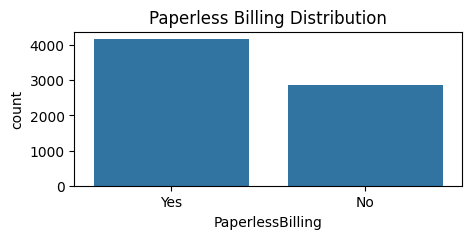

In [ ]:
# Distribution of PaperlessBilling
plt.figure(figsize=(5,2))
sns.countplot(x='PaperlessBilling', data=data)
plt.title("Paperless Billing Distribution")
plt.show()

**Insights**

* The **‘Yes’ category** has a **higher count**, indicating most customers **prefer paperless billing**.
* The **‘No’ category** is **lower**, showing fewer users still rely on **traditional billing methods**.
* There is a **clear difference** between the two groups, suggesting a **strong shift toward digital billing**.
* Overall, customers show a **growing adoption of online services**, reflecting **modern usage trends**.


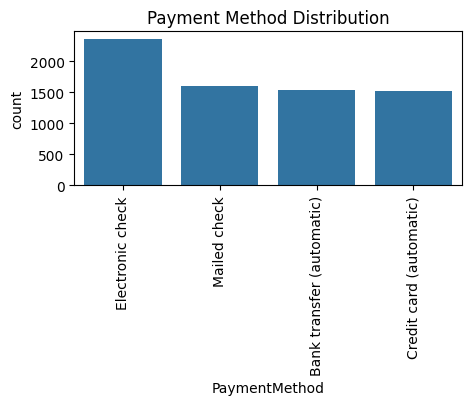

In [ ]:
# Distribution of PaymentMethod
plt.figure(figsize=(5,2))
sns.countplot(x='PaymentMethod', data=data)
plt.title("Payment Method Distribution")
plt.xticks(rotation=90)
plt.show()

**Insights**

* The **‘Electronic check’ method** has the **highest count**, indicating it is the **most commonly used payment option**.
* The **‘Mailed check’** is **less popular**, showing fewer users prefer **traditional payment methods**.
* The **‘Bank transfer (automatic)’** and **‘Credit card (automatic)’** have **similar counts**, suggesting a **balanced preference for automatic payments**.
* Overall, there is a **mix of digital and traditional methods**, but **electronic payments dominate usage**.


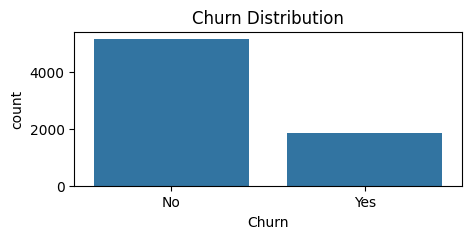

In [ ]:
# Distribution of Churn
plt.figure(figsize=(5,2))
sns.countplot(x='Churn', data=data)
plt.title("Churn Distribution")
plt.show()

**Insights**

* The **‘No churn’ category** has a **significantly higher count**, indicating most customers **continue using the service**.
* The **‘Yes churn’ category** is **much lower**, showing a **smaller portion of customers leave**.
* There is a **large gap between retained and churned customers**, suggesting **good customer retention overall**.
* However, the presence of churn still indicates a **need to analyze reasons for customer loss**.


**8.2 Bivariate Analysis**

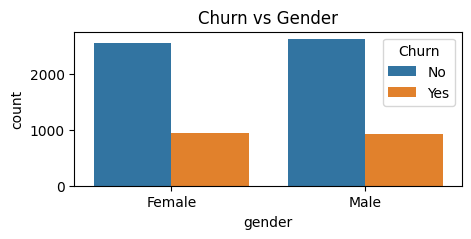

In [ ]:
# How does Churn vary with gender
plt.figure(figsize=(5,2))
sns.countplot(x='gender', hue='Churn', data=data)
plt.title("Churn vs Gender")
plt.show()

**Insights**

* **Male customers** have a **slightly higher churn count** compared to **female customers**, indicating a marginal difference.

* For both **genders**, the number of customers who did **not churn (No)** is **significantly higher** than those who **churned (Yes)**.

* The **churn rate appears similar** across **male and female groups**, suggesting **gender is not a strong factor** influencing churn.

* The overall distribution shows a **balanced gender participation**, with **no major disparity** in total counts between males and females.


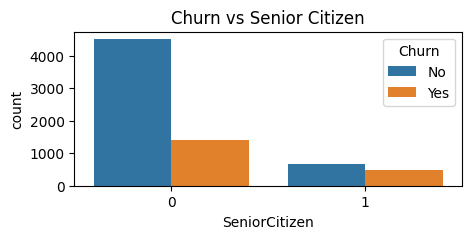

In [ ]:
# How does Churn vary with SeniorCitizen
plt.figure(figsize=(5,2))
sns.countplot(x='SeniorCitizen', hue='Churn', data=data)
plt.title("Churn vs Senior Citizen")
plt.show()

**Insights**

* **Non-senior citizens (0)** have a **much higher total count** compared to **senior citizens (1)**, indicating most customers are non-seniors.

* Among **non-senior citizens**, the number of customers who did **not churn** is **significantly higher** than those who **churned**.

* For **senior citizens**, the **gap between churn (Yes) and non-churn (No)** is **smaller**, suggesting a **higher churn tendency** in this group.

* Overall, **senior citizens show a relatively higher churn proportion**, even though their **total population is lower**.


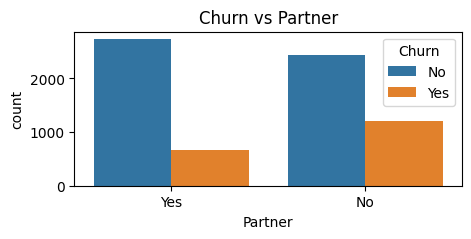

In [ ]:
# How does Churn vary with Partner
plt.figure(figsize=(5,2))
sns.countplot(x='Partner', hue='Churn', data=data)
plt.title("Churn vs Partner")
plt.show()

**Insights**

* Customers **without a partner (No)** have a **higher churn count** compared to those **with a partner (Yes)**.

* Customers **with a partner** show a **much lower churn (Yes)** and **higher retention (No)**, indicating better loyalty.

* The **gap between churn and non-churn** is **larger for customers with a partner**, suggesting they are **less likely to leave**.

* Overall, having a **partner appears to reduce churn risk**, making it an **important influencing factor**.


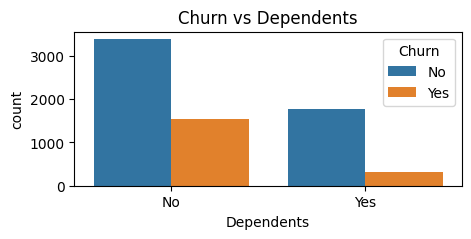

In [ ]:
# How does Churn vary with Dependents
plt.figure(figsize=(5,2))
sns.countplot(x='Dependents', hue='Churn', data=data)
plt.title("Churn vs Dependents")
plt.show()

**Insights**

* Customers **without dependents (No)** have a **much higher churn count** compared to those **with dependents (Yes)**.

* Customers **with dependents** show a **significantly lower churn (Yes)** and **higher retention (No)**, indicating stronger stability.

* The **gap between churn and non-churn** is **larger for customers with dependents**, suggesting they are **less likely to leave**.

* Overall, having **dependents reduces churn risk**, making it an **important factor influencing customer retention**.


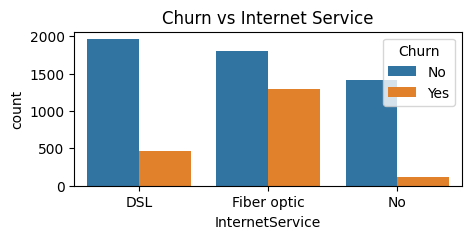

In [ ]:
# How does Churn vary with InternetService
plt.figure(figsize=(5,2))
sns.countplot(x='InternetService', hue='Churn', data=data)
plt.title("Churn vs Internet Service")
plt.show()

**Insights**

* Customers using **Fiber optic** service have the **highest churn count**, indicating a **higher dissatisfaction or risk** in this segment.

* **DSL users** show a **much lower churn (Yes)** and **higher retention (No)** compared to fiber users.

* Customers with **no internet service** have the **lowest churn count**, suggesting **minimal risk** in this group.

* Overall, **type of internet service strongly impacts churn**, with **fiber optic users most likely to churn**.


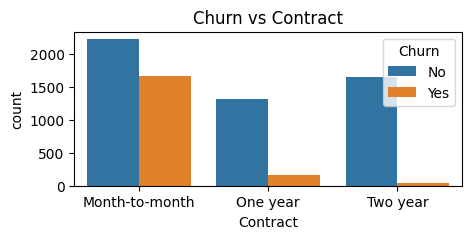

In [ ]:
# How does Churn vary with Contract
plt.figure(figsize=(5,2))
sns.countplot(x='Contract', hue='Churn', data=data)
plt.title("Churn vs Contract")
plt.show()

**Insights**

* **Month-to-month contracts** show the **highest churn**, indicating customers on **short-term plans** are more likely to leave.

* **One-year contracts** have a **significantly lower churn rate**, suggesting **longer commitment** improves customer retention.

* **Two-year contracts** exhibit the **lowest churn**, highlighting that **long-term agreements** strongly reduce customer loss.

* There is a clear **inverse relationship** between **contract length** and **churn rate**—as **contract duration increases**, **churn decreases**.


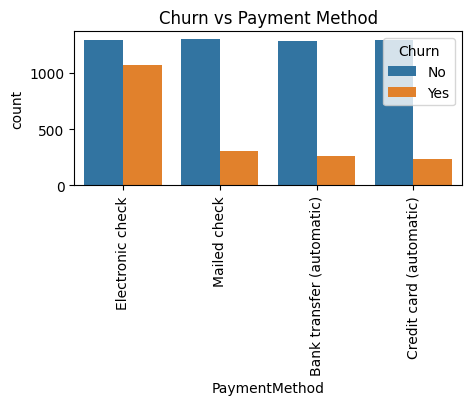

In [ ]:
# How does Churn vary with PaymentMethod
plt.figure(figsize=(5,2))
sns.countplot(x='PaymentMethod', hue='Churn', data=data)
plt.title("Churn vs Payment Method")
plt.xticks(rotation=90)
plt.show()

**Insights**

* **Electronic check** users have the **highest churn**, indicating this **payment method** is linked to **greater customer attrition**.

* **Mailed check** shows **moderate churn**, but still significantly lower than **electronic check**, suggesting **payment convenience** may influence retention.

* **Automatic payments** (like **bank transfer** and **credit card**) have the **lowest churn rates**, highlighting the impact of **auto-pay stability** on retention.

* There is a clear trend where **manual payment methods** lead to **higher churn**, while **automated methods** contribute to **better customer retention**.


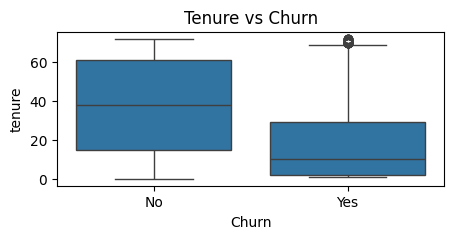

In [ ]:
# How does tenure differ by Churn
plt.figure(figsize=(5,2))
sns.boxplot(x='Churn', y='tenure', data=data)
plt.title("Tenure vs Churn")
plt.show()

**Insights**

* Customers who **did not churn** have a **higher median tenure**, indicating **long-term customers** are more likely to stay.

* Customers who **churned** show a **much lower tenure**, suggesting **early-stage customers** are at higher risk of leaving.

* The **tenure distribution** for non-churned customers is **wider**, meaning they are spread across **short to very long durations**, unlike churned users.

* A few **high-tenure churn cases** exist, but they are **outliers**, showing that even **loyal customers** can occasionally leave.


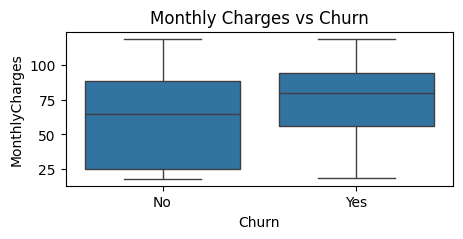

In [ ]:
# How does MonthlyCharges differ by Churn
plt.figure(figsize=(5,2))
sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title("Monthly Charges vs Churn")
plt.show()

**Insights**

* Customers who **churn (Yes)** have a **higher median monthly charge** compared to those who do not churn, indicating **cost may influence churn behavior**.

* The **spread (variability)** of charges is **wide for both groups**, but slightly **more concentrated for churned customers**, suggesting a **more consistent pricing range** among them.

* A **large portion of non-churn customers** fall in the **lower charge range**, implying **lower pricing may help retain customers**.

* There is an **overlap in charge ranges** between churned and non-churned users, meaning **monthly charges alone are not the only factor driving churn**.


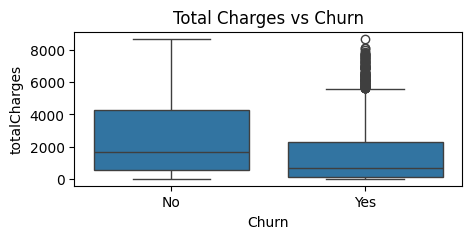

In [ ]:
# How does totalCharges differ by Churn
plt.figure(figsize=(5,2))
sns.boxplot(x='Churn', y='totalCharges', data=data)
plt.title("Total Charges vs Churn")
plt.show()

**Insights**

* Customers who **do not churn (No)** have a **higher median total charges**, indicating they likely **stay longer and accumulate more charges over time**.

* Customers who **churn (Yes)** show a **lower median total charge**, suggesting they tend to **leave earlier in their lifecycle**.

* The **non-churn group** has a **much wider spread**, including very **high total charges**, reinforcing that **long-term customers contribute more revenue**.

* There are **several high-value outliers in the churn group**, meaning **some high-paying customers still leave**, so **factors beyond total spend influence churn**.


**8.3 Multivariate Analysis**

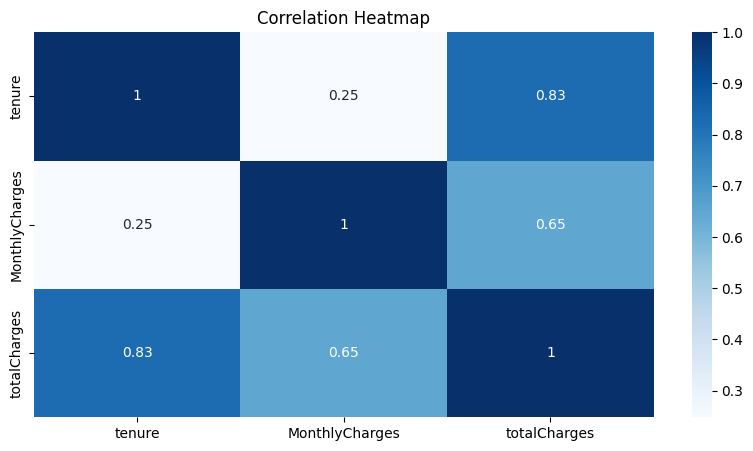

In [ ]:
# Correlation between numerical features
plt.figure(figsize=(10,5))
corr = data[['tenure', 'MonthlyCharges', 'totalCharges']].corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

**Insights**

* **Tenure and Total Charges** show a **strong positive correlation (0.83)**, indicating that customers who **stay longer accumulate higher total charges**.

* **Monthly Charges and Total Charges** have a **moderate to strong correlation (0.65)**, meaning **higher monthly payments contribute significantly to overall revenue**.

* **Tenure and Monthly Charges** have a **weak correlation (0.25)**, suggesting that **how long a customer stays is not strongly linked to how much they pay monthly**.

* Overall, **Total Charges** is highly influenced by both **tenure and monthly charges**, making it a **key combined indicator of customer value**.


# **9. Detect and Handle Outliers**

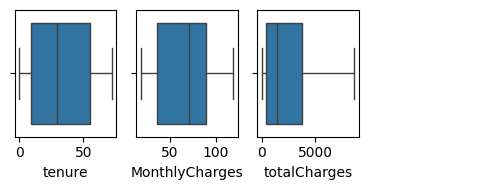

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(5,2))
sns.boxplot(data=data, x='tenure', ax=ax[0])
sns.boxplot(data=data, x='MonthlyCharges', ax=ax[1])
sns.boxplot(data=data, x='totalCharges', ax=ax[2])
ax[3].axis('off')

plt.tight_layout()
plt.show()

There are **no outliers** in the data

# **10. Encoding**

In [ ]:
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


**Churn, gender, Partner, Dependents, PhoneService, PaperlessBilling - Label Encoder**

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data.loc[:,'churn']= le.fit_transform(data.loc[:,'Churn'])
data.loc[:,'Gender']= le.fit_transform(data.loc[:,'gender'])
data['partner'] = le.fit_transform(data['Partner'])
data['dependents'] = le.fit_transform(data['Dependents'])
data['phoneService'] = le.fit_transform(data['PhoneService'])
data['paperlessBilling'] = le.fit_transform(data['PaperlessBilling'])

In [ ]:
data.drop(columns=['Churn','gender','Partner','Dependents','PhoneService','PaperlessBilling'],inplace=True)

**MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod - One-Hot Encoding**

In [ ]:
data =pd.get_dummies(data,columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod'],dtype='int')

In [ ]:
data.dtypes

,0
customerID,object
SeniorCitizen,int64
tenure,int64
MonthlyCharges,float64
totalCharges,float64
churn,int64
Gender,int64
partner,int64
dependents,int64
phoneService,int64


In [ ]:
data

,customerID,SeniorCitizen,tenure,MonthlyCharges,totalCharges,churn,Gender,partner,dependents,phoneService,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,29.85,29.85,0,0,1,0,0,...,1,0,0,1,0,0,0,0,1,0
1,5575-GNVDE,0,34,56.95,1889.50,0,1,0,0,1,...,1,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0,2,53.85,108.15,1,1,0,0,1,...,1,0,0,1,0,0,0,0,0,1
3,7795-CFOCW,0,45,42.30,1840.75,0,1,0,0,0,...,1,0,0,0,1,0,1,0,0,0
4,9237-HQITU,0,2,70.70,151.65,1,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,0,24,84.80,1990.50,0,1,1,1,1,...,0,0,1,0,1,0,0,0,0,1
7039,2234-XADUH,0,72,103.20,7362.90,0,0,1,1,1,...,0,0,1,0,1,0,0,1,0,0
7040,4801-JZAZL,0,11,29.60,346.45,0,0,1,1,0,...,1,0,0,1,0,0,0,0,1,0
7041,8361-LTMKD,1,4,74.40,306.60,1,1,1,0,1,...,1,0,0,1,0,0,0,0,0,1


# **11. Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
num_cols = ['tenure', 'MonthlyCharges', 'totalCharges']
scaler = StandardScaler()
data[num_cols] = scaler.fit_transform(data[num_cols])

In [ ]:
data

,customerID,SeniorCitizen,tenure,MonthlyCharges,totalCharges,churn,Gender,partner,dependents,phoneService,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,-1.277445,-1.160252,-0.991778,0,0,1,0,0,...,1,0,0,1,0,0,0,0,1,0
1,5575-GNVDE,0,0.066327,-0.259300,-0.171492,0,1,0,0,1,...,1,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,0,-1.236724,-0.362361,-0.957240,1,1,0,0,1,...,1,0,0,1,0,0,0,0,0,1
3,7795-CFOCW,0,0.514251,-0.746346,-0.192996,0,1,0,0,0,...,1,0,0,0,1,0,1,0,0,0
4,9237-HQITU,0,-1.236724,0.197824,-0.938053,1,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,0,-0.340876,0.666585,-0.126941,0,1,1,1,1,...,0,0,1,0,1,0,0,0,0,1
7039,2234-XADUH,0,1.613701,1.278301,2.242808,0,0,1,1,1,...,0,0,1,0,1,0,0,1,0,0
7040,4801-JZAZL,0,-0.870241,-1.168563,-0.852127,0,0,1,1,0,...,1,0,0,1,0,0,0,0,1,0
7041,8361-LTMKD,1,-1.155283,0.320832,-0.869705,1,1,1,0,1,...,1,0,0,1,0,0,0,0,0,1


# **12. Feature Selection**

In [ ]:
data.drop(columns=['customerID'], axis=1, inplace=True)

In [ ]:
data.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'totalCharges', 'churn',
       'Gender', 'partner', 'dependents', 'phoneService', 'paperlessBilling',
       'MultipleLines_No', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No',
       'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMetho

# **13. Separate Features and Target Variable**

**Split Data for X and Y**

In [ ]:
x=data.drop(columns='churn')
y=data.loc[:,'churn']

# **14. Train-Test Split**

**Split Data for Training and Testing**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
data.shape

(7043, 41)

In [ ]:
x_train.shape

(5634, 40)

In [ ]:
x_test.shape

(1409, 40)

In [ ]:
y_train.shape

(5634,)

In [ ]:
y_test.shape

(1409,)

# **15. Balancing data**

<Axes: xlabel='churn', ylabel='count'>

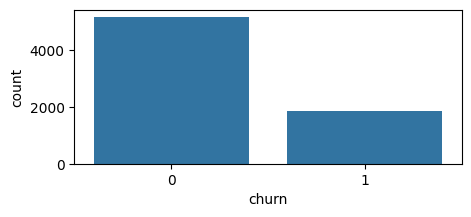

In [ ]:
# plot count plot for target
plt.figure(figsize=(5,2))
sns.countplot(data,x='churn')

**Data is Imbalanced.**

In [ ]:
# Smote
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
x_sampled,y_sampled = smote.fit_resample(x_train,y_train)

In [ ]:
# before balancing
Counter(y_train)

Counter({0: 4138, 1: 1496})

In [ ]:
# after balancing
Counter(y_sampled)

Counter({0: 4138, 1: 4138})

# **16. Model Building and Evaluation**

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score
from sklearn.metrics import roc_auc_score,roc_curve

**a. Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_sampled,y_sampled)
y_pred =model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#confusion matrix
confusion_matrix(y_test,y_pred)

array([[841, 195],
       [ 93, 280]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7955997161107168

In [ ]:
# recall
recall_score(y_test,y_pred)

0.7506702412868632

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5894736842105263

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.660377358490566

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7812231515314625)

**b. Decision Tree Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini',splitter='best',max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[800, 236],
       [135, 238]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7366926898509581

In [ ]:
# recall
recall_score(y_test,y_pred)

0.6380697050938338

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5021097046413502

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.5619834710743802

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.705135238647303)

**c. Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=10,max_depth=6,max_features=5,bootstrap=True,min_samples_split=5,min_samples_leaf=3)
model.fit(x_sampled,y_sampled)
y_pred=model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[753, 283],
       [ 69, 304]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7501774308019872

In [ ]:
# recall
recall_score(y_test,y_pred)

0.8150134048257373

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5178875638841567

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6333333333333333

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7709236908298571)

**d. Gradient Boosting Classifier**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier()
model.fit(x_sampled,y_sampled)
y_pred= model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[804, 232],
       [ 79, 294]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7792760823278921

In [ ]:
# recall
recall_score(y_test,y_pred)

0.7882037533512064

In [ ]:
# precision
precision_score(y_test,y_pred)

0.55893536121673

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6540600667408232

In [ ]:
# roc_auc_curve
roc_auc_score(y_test,y_pred)

np.float64(0.7821327647064913)

**e. XGBoost Classifier**

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier()
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[860, 176],
       [132, 241]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7814052519517388

In [ ]:
# recall
recall_score(y_test,y_pred)

0.646112600536193

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5779376498800959

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.610126582278481

In [ ]:
# roc_auc_curve
roc_auc_score(y_test,y_pred)

np.float64(0.7381142153260115)

**f. KNN Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
#confusion matrix
confusion_matrix(y_test,y_pred)

array([[758, 278],
       [108, 265]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7260468417317246

In [ ]:
# recall
recall_score(y_test,y_pred)

0.710455764075067

In [ ]:
# precision
precision_score(y_test,y_pred)

0.4880294659300184

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.5786026200873362

In [ ]:
# roc curve
roc_auc_score(y_test,y_pred)

np.float64(0.7210579978676493)

**g. SVM Classifier**

In [ ]:
from sklearn.svm import SVC
model = SVC()
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[847, 189],
       [105, 268]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7913413768630234

In [ ]:
# recall
recall_score(y_test,y_pred)

0.7184986595174263

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5864332603938731

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6457831325301204

In [ ]:
# roc_auc_curve
roc_auc_score(y_test,y_pred)

np.float64(0.7680331135424969)

# **17. Cross validation**

In [ ]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold

**a. Logistic Regression**

**K Fold**

In [ ]:
model = LogisticRegression()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=kfold)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
scores

array([0.82548309, 0.81450151, 0.8265861 , 0.80483384, 0.84350453])

In [ ]:
print(np.mean(scores))

0.8229818147321103


**Startified K Fold**

In [ ]:
model = LogisticRegression()
sfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=sfold)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
scores

array([0.8218599 , 0.82779456, 0.81450151, 0.8326284 , 0.81933535])

In [ ]:
print(np.mean(scores))

0.823223944422552


**b. Decision Tree Classifier**

**K Fold**

In [ ]:
model = DecisionTreeClassifier(criterion='gini',splitter='best',max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
kfold = KFold(n_splits=5, shuffle=True,random_state=42)
scores=cross_val_score(model,x_sampled,y_sampled,cv=kfold)

In [ ]:
scores

array([0.77777778, 0.74984894, 0.76314199, 0.77220544, 0.7939577 ])

In [ ]:
print(np.mean(scores))

0.7713863712655253


**Startified K Fold**

In [ ]:
model = DecisionTreeClassifier(criterion='gini',splitter='best',max_features='sqrt',min_samples_split=5,min_samples_leaf=3)
sfold = StratifiedKFold(n_splits=5, shuffle=True,random_state=42)
scores= cross_val_score(model,x_sampled,y_sampled,cv=sfold)

In [ ]:
scores

array([0.77596618, 0.77703927, 0.76858006, 0.77220544, 0.76918429])

In [ ]:
print(np.mean(scores))

0.7725950494037976


**c. Random Forest Classifier**

**K Fold**

In [ ]:
model = RandomForestClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=kfold)

In [ ]:
scores

array([0.85144928, 0.83504532, 0.84773414, 0.84169184, 0.8592145 ])

In [ ]:
print(np.mean(scores))

0.8470270151933097


**Startified K Fold**

In [ ]:
sfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=sfold)

In [ ]:
scores

array([0.8423913 , 0.8489426 , 0.84712991, 0.84229607, 0.84410876])

In [ ]:
print(np.mean(scores))

0.8449737291475108


**d. Gradient Boosting Classifier**

**K Fold**

In [ ]:
model = GradientBoostingClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=kfold)

In [ ]:
scores

array([0.81642512, 0.80906344, 0.8163142 , 0.80785498, 0.83141994])

In [ ]:
print(np.mean(scores))

0.8162155377497555


**Startified K Fold**

In [ ]:
sfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=sfold)

In [ ]:
scores

array([0.81280193, 0.81450151, 0.81570997, 0.82779456, 0.82114804])

In [ ]:
print(np.mean(scores))

0.8183912021833997


**e. XGBoost Classifier**

**K Fold**

In [ ]:
model = XGBClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=kfold)

In [ ]:
scores

array([0.84903382, 0.8265861 , 0.83141994, 0.83564955, 0.86404834])

In [ ]:
print(np.mean(scores))

0.8413475487835136


**Startified K Fold**

In [ ]:
sfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=sfold)

In [ ]:
scores

array([0.83152174, 0.84169184, 0.83987915, 0.84410876, 0.83625378])

In [ ]:
print(np.mean(scores))

0.8386910547747274


**f. KNN Classifier**

**K Fold**

In [ ]:
model = KNeighborsClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=kfold)

In [ ]:
scores

array([0.80736715, 0.81993958, 0.81087613, 0.81389728, 0.82779456])

In [ ]:
print(np.mean(scores))

0.815974940525709


**Startified K Fold**

In [ ]:
sfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=sfold)

In [ ]:
scores

array([0.80434783, 0.81993958, 0.81148036, 0.82416918, 0.81873112])

In [ ]:
print(np.mean(scores))

0.8157336135557598


**g. SVM Classifier**

**K Fold**

In [ ]:
model = SVC()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=kfold)

In [ ]:
scores

array([0.83031401, 0.81148036, 0.82719033, 0.81329305, 0.84592145])

In [ ]:
print(np.mean(scores))

0.8256398412072915


**Startified K Fold**

In [ ]:
sfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, x_sampled, y_sampled, cv=sfold)

In [ ]:
scores

array([0.81521739, 0.82175227, 0.82537764, 0.83685801, 0.82960725])

In [ ]:
print(np.mean(scores))

0.825762511493498


# **18. Hyper parameter tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

**a. Logistic Regression**

**Grid SearchCV**

In [ ]:
model = LogisticRegression(max_iter=1000)
parameters = {
    'C':[0.01,0.1,1,10],
    'penalty':['l2'],
    'solver':['lbfgs','liblinear']
}
grid = GridSearchCV(estimator=model, param_grid=parameters, cv=5)
grid.fit(x_sampled, y_sampled)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'],
                         'solver': ['lbfgs', 'liblinear']})

In [ ]:
print(grid.best_params_)

{'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


In [ ]:
model = LogisticRegression(C=10, penalty='l2',solver='lbfgs')
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[848, 188],
       [ 98, 275]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7970191625266146

In [ ]:
# recall
recall_score(y_test,y_pred)

0.7372654155495979

In [ ]:
# precision
precision_score(y_test,y_pred)

0.593952483801296

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6578947368421053

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7778991170412083)

**Randomized SearchCV**

In [ ]:
model = LogisticRegression(max_iter=1000)
parameters = {
    'C':[0.01,0.1,1,10],
    'penalty':['l2'],
    'solver':['lbfgs','liblinear']
}
random = RandomizedSearchCV(estimator=model,
                            param_distributions=parameters,
                            cv=5, n_iter=10)
random.fit(x_sampled, y_sampled)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
                   param_distributions={'C': [0.01, 0.1, 1, 10],
                                        'penalty': ['l2'],
                                        'solver': ['lbfgs', 'liblinear']})

In [ ]:
print(random.best_params_)

{'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}


In [ ]:
model = LogisticRegression(C=10, penalty='l2',solver='lbfgs')
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[848, 188],
       [ 98, 275]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7970191625266146

In [ ]:
# recall
recall_score(y_test,y_pred)

0.7372654155495979

In [ ]:
# precision
precision_score(y_test,y_pred)

0.593952483801296

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6578947368421053

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7778991170412083)

**b. Decision Tree Classifier**

**Grid SearchCV**

In [ ]:
model = DecisionTreeClassifier()
parameters = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,7,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}
grid = GridSearchCV(estimator=model, param_grid=parameters, cv=5)
grid.fit(x_sampled, y_sampled)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]})

In [ ]:
print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [ ]:
model = DecisionTreeClassifier(criterion = 'gini', max_depth = 10, min_samples_leaf = 1, min_samples_split = 10)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[779, 257],
       [100, 273]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7466288147622427

In [ ]:
# recall
recall_score(y_test,y_pred)

0.7319034852546917

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5150943396226415

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6046511627906976

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7419169935925969)

**Randomized SearchCV**

In [ ]:
model = DecisionTreeClassifier()
parameters = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,7,10],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}
random = RandomizedSearchCV(estimator=model,
                            param_distributions=parameters,
                            cv=5, n_iter=10)
random.fit(x_sampled, y_sampled)

RandomizedSearchCV(cv=5, estimator=DecisionTreeClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 5, 7, 10],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10]})

In [ ]:
print(random.best_params_)

{'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10, 'criterion': 'gini'}


In [ ]:
model = DecisionTreeClassifier(criterion = 'gini', max_depth = 10, min_samples_leaf = 2, min_samples_split = 10)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[782, 254],
       [102, 271]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7473385379701917

In [ ]:
# recall
recall_score(y_test,y_pred)

0.7265415549597856

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5161904761904762

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6035634743875279

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7406839048930202)

**c. Random Forest Classifier**

**Grid SearchCV**

In [ ]:
model = RandomForestClassifier()
parameters = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}
grid = GridSearchCV(estimator=model, param_grid=parameters, cv=5)
grid.fit(x_sampled, y_sampled)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, 15], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]})

In [ ]:
print(grid.best_params_)

{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
model = RandomForestClassifier(n_estimators = 200, max_depth = 15, min_samples_leaf = 1, min_samples_split = 2)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[843, 193],
       [113, 260]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7828246983676366

In [ ]:
# recall
recall_score(y_test,y_pred)

0.6970509383378016

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5739514348785872

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6295399515738499

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7553787510221825)

**Randomized SearchCV**

In [ ]:
model = RandomForestClassifier()
parameters = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}
random = RandomizedSearchCV(estimator=model,
                            param_distributions=parameters,
                            cv=5, n_iter=10)
random.fit(x_sampled, y_sampled)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(),
                   param_distributions={'max_depth': [5, 10, 15],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [100, 200, 300]})

In [ ]:
print(random.best_params_)

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15}


In [ ]:
model = RandomForestClassifier(n_estimators = 300, max_depth = 15, min_samples_leaf = 1, min_samples_split = 2)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[846, 190],
       [115, 258]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7835344215755855

In [ ]:
# recall
recall_score(y_test,y_pred)

0.6916890080428955

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5758928571428571

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6285018270401949

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.754145662322606)

**d. Gradient Boosting Classifier**

**Grid SearchCV**

In [ ]:
model = GradientBoostingClassifier()
parameters = {'max_depth':[3,4,4],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.2,0.3]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid.fit(x_sampled,y_sampled)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.01, 0.2, 0.3],
                         'max_depth': [3, 4, 4],
                         'n_estimators': [100, 200, 300]})

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}


In [ ]:
model = GradientBoostingClassifier(learning_rate=0.2, max_depth=4, n_estimators=200)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[855, 181],
       [131, 242]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7785663591199432

In [ ]:
# recall
recall_score(y_test,y_pred)

0.6487935656836461

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5721040189125296

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6080402010050251

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7370415704866107)

**Randomized SearchCV**

In [ ]:
model = GradientBoostingClassifier()
parameters = {'max_depth':[3,4,4],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.2,0.3]}
random = RandomizedSearchCV(estimator=model ,
                            param_distributions=parameters,cv=5,n_iter=20)
random.fit(x_sampled,y_sampled)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_iter=20,
                   param_distributions={'learning_rate': [0.01, 0.2, 0.3],
                                        'max_depth': [3, 4, 4],
                                        'n_estimators': [100, 200, 300]})

In [ ]:
print(random.best_params_)

{'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.2}


In [ ]:
model = GradientBoostingClassifier(n_estimators=300, max_depth= 4
                                   , learning_rate=0.2)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[865, 171],
       [136, 237]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7821149751596878

In [ ]:
# recall
recall_score(y_test,y_pred)

0.6353887399463807

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5808823529411765

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6069142125480154

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7351654124442328)

**e. XGBoost Classifier**

**Grid SearchCV**

In [ ]:
model = XGBClassifier()
parameters = {'max_depth':[3,4,4],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.2,0.3],'reg_alpha':[0.1,0.01],
              'reg_lambda':[0.01,0.2,0.3]}
grid = GridSearchCV(estimator=model,param_grid=parameters,cv=5)
grid.fit(x_sampled,y_sampled)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.2, 0.3],
                         'max_depth': [3, 4, 4],
                         'n_estimators': [100, 200, 300],
                         'reg_alpha': [0.1, 0.01],
                         'reg_lambda': [0.01, 0.2, 0.3]})

In [ ]:
print(grid.best_params_)

{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 0.2}


In [ ]:
model = XGBClassifier(learning_rate= 0.2,
                      max_depth=4, n_estimators= 100,
                      reg_alpha= 0.1, reg_lambda= 0.2)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[848, 188],
       [102, 271]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.794180269694819

In [ ]:
# recall
recall_score(y_test,y_pred)

0.7265415549597856

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5904139433551199

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6514423076923077

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7725371867463021)

**Randomized SearchCV**

In [ ]:
model = XGBClassifier()
parameters = {'max_depth':[3,4,4],'n_estimators':[100,200,300],
              'learning_rate':[0.01,0.2,0.3],'reg_alpha':[0.1,0.01],
              'reg_lambda':[0.01,0.2,0.3]}
random = RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=5,n_iter=20)
random.fit(x_sampled,y_sampled)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20,
                   param_distributions={'learning_rate': [0.01, 0.2, 0.3],
                                        'max_depth': [3, 4, 4],
                                        'n_estimators': [100, 200, 300],
                                        'reg_alpha': [0.1, 0.01],
                                        'reg_lambda': [0.01, 0.2, 0.3]})

In [ ]:
print(random.best_params_)

{'reg_lambda': 0.2, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.2}


In [ ]:
model = XGBClassifier(reg_lambda= 0.2, reg_alpha= 0.1,
                       n_estimators= 200, max_depth= 4,
                      learning_rate= 0.2)
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[861, 175],
       [119, 254]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7913413768630234

In [ ]:
# recall
recall_score(y_test,y_pred)

0.6809651474530831

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5920745920745921

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6334164588528678

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7560231142670821)

**f. KNN Classifier**

**Grid SearchCV**

In [ ]:
model = KNeighborsClassifier()
parameters = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}
grid = GridSearchCV(estimator=model, param_grid=parameters, cv=5)
grid.fit(x_sampled, y_sampled)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [ ]:
print(grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}


In [ ]:
model = KNeighborsClassifier(metric = 'manhattan', n_neighbors = 3, weights = 'uniform')
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[783, 253],
       [125, 248]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7317246273953159

In [ ]:
# recall
recall_score(y_test,y_pred)

0.6648793565683646

In [ ]:
# precision
precision_score(y_test,y_pred)

0.49500998003992014

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.5675057208237986

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7103354311799353)

**Randomized SearchCV**

In [ ]:
model = KNeighborsClassifier()
parameters = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}
random = RandomizedSearchCV(estimator=model,
                            param_distributions=parameters,
                            cv=5, n_iter=10)
random.fit(x_sampled, y_sampled)

RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(),
                   param_distributions={'metric': ['euclidean', 'manhattan'],
                                        'n_neighbors': [3, 5, 7, 9],
                                        'weights': ['uniform', 'distance']})

In [ ]:
print(random.best_params_)

{'weights': 'distance', 'n_neighbors': 5, 'metric': 'manhattan'}


In [ ]:
model = KNeighborsClassifier(metric = 'manhattan', n_neighbors = 5, weights = 'distance')
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[781, 255],
       [124, 249]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7310149041873669

In [ ]:
# recall
recall_score(y_test,y_pred)

0.6675603217158177

In [ ]:
# precision
precision_score(y_test,y_pred)

0.49404761904761907

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.5678449258836944

In [ ]:
# roc_auc_score
roc_auc_score(y_test,y_pred)

np.float64(0.7107106627884108)

**g. SVM Classifier**

**Grid SearchCV**

In [ ]:
model = SVC()
parameters = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 0.01, 0.001],
    'gamma': [0.1, 1, 5, 10]
}
grid = GridSearchCV(estimator=model, param_grid=parameters, cv=5, scoring='accuracy')
grid.fit(x_sampled, y_sampled)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 0.01, 0.001], 'gamma': [0.1, 1, 5, 10],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [ ]:
print(grid.best_params_)

{'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}


In [ ]:
model = SVC(C=0.1,gamma=0.1,kernel='linear')
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[820, 216],
       [ 90, 283]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7828246983676366

In [ ]:
# recall
recall_score(y_test,y_pred)

0.7587131367292225

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5671342685370742

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6490825688073395

In [ ]:
# roc_auc_curve
roc_auc_score(y_test,y_pred)

np.float64(0.7751094641175069)

**Randomized SearchCV**

In [ ]:
model = SVC()
parameters = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 0.01, 0.001],
    'gamma': [0.1, 1, 5, 10]
}
random = RandomizedSearchCV(estimator=model,param_distributions=parameters,cv=3,n_iter=10)
random.fit(x_sampled, y_sampled)

RandomizedSearchCV(cv=3, estimator=SVC(),
                   param_distributions={'C': [0.1, 0.01, 0.001],
                                        'gamma': [0.1, 1, 5, 10],
                                        'kernel': ['linear', 'rbf']})

In [ ]:
print(random.best_params_)

{'kernel': 'linear', 'gamma': 5, 'C': 0.1}


In [ ]:
model = SVC(C=0.1,gamma=5,kernel='linear')
model.fit(x_sampled,y_sampled)
y_pred = model.predict(x_test)

In [ ]:
# confusion matrix
confusion_matrix(y_test,y_pred)

array([[820, 216],
       [ 90, 283]])

In [ ]:
# accuracy
accuracy_score(y_test,y_pred)

0.7828246983676366

In [ ]:
# recall
recall_score(y_test,y_pred)

0.7587131367292225

In [ ]:
# precision
precision_score(y_test,y_pred)

0.5671342685370742

In [ ]:
# f1 score
f1_score(y_test,y_pred)

0.6490825688073395

In [ ]:
# roc_auc_curve
roc_auc_score(y_test,y_pred)

np.float64(0.7751094641175069)

# **19. Compare Model Performance**

**Create comparison table**

In [ ]:
data = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "KNN",
        "SVM"
    ],
    "Accuracy": [0.7955, 0.7608, 0.7657, 0.7792, 0.7814, 0.7260,0.7913],
    "Recall": [0.7506, 0.6648, 0.8150, 0.7882, 0.6461, 0.7104,0.7184],
    "Precision": [0.5894, 0.5391, 0.5380, 0.5589, 0.5779, 0.4880,0.5864],
    "F1 Score": [0.6603, 0.5954, 0.6481, 0.6540, 0.6101, 0.5786,0.6457],
    "ROC-AUC": [0.7812, 0.7301, 0.7815, 0.7821, 0.7381, 0.7210,0.7680]
}

# Create DataFrame
df = pd.DataFrame(data)

# Display table
print(df)

                 Model  Accuracy  Recall  Precision  F1 Score  ROC-AUC
0  Logistic Regression    0.7955  0.7506     0.5894    0.6603   0.7812
1        Decision Tree    0.7608  0.6648     0.5391    0.5954   0.7301
2        Random Forest    0.7657  0.8150     0.5380    0.6481   0.7815
3    Gradient Boosting    0.7792  0.7882     0.5589    0.6540   0.7821
4              XGBoost    0.7814  0.6461     0.5779    0.6101   0.7381
5                  KNN    0.7260  0.7104     0.4880    0.5786   0.7210
6                  SVM    0.7913  0.7184     0.5864    0.6457   0.7680


**Identify best model**

Gradient Boosting performed best overall with the highest ROC-AUC and balanced recall and precision. However, Random Forest had the highest recall, making it better if the goal is to identify maximum churn customers.

# **20. Select Best Model**

**Based on metrics**

Gradient Boosting Classifier

- Highest ROC-AUC (0.7821) → best overall class separation
- Good Accuracy (0.7792) → strong overall correctness
- Strong Recall (0.7882) → captures most churn customers
- Balanced F1-score (0.6540) → good trade-off between precision and recall

**Business interpretation**

- In customer churn prediction, recall is very important
- Missing a churn customer leads to direct revenue loss
- Gradient Boosting provides a balanced approach:
  - High recall → identifies most churn customers
  - Better precision than Random Forest → avoids excessive false alarms
- Helps the business:
  - Target the right customers for retention campaigns
  - Reduce unnecessary marketing costs
- Random Forest can be an alternative when:
  - The goal is to maximize churn detection
  - It has the highest recall (0.8150) but lower precision

# **21. Final Insights**

**Key factors influencing Churn**

- High monthly charges → Higher churn
- Month-to-month contracts → Higher churn
- No tech support → Higher churn
- Short tenure → Higher churn

**Business recommendations**

- Offer long-term contract discounts
- Improve customer support services
- Provide personalized retention offers
- Identify high-risk customers early
- Reduce churn through loyalty programs